In [8]:
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from scipy.stats import sem, t

plt.style.use('classic')
%matplotlib inline

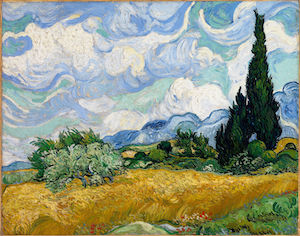

In [9]:
display(REFERENCE_IMAGE)

In [10]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = True

In [11]:
def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(f"./img/van_gogh_intermediate_{evo.seed}_{evo.population_size}_{evo.crossover_method}_{evo.num_points}_{evo.initialization}_{evo.generation_budget}_{time['num-generations']:05d}.png")

def run_algorithm(settings):
    seed, population_size, crossover_method, num_points, initialization, generation_budget = settings
    start = time()
    
    data = []
    evo = Evolution(num_points,
                    REFERENCE_IMAGE,
                    population_size=population_size,
                    generation_reporter=reporter,
                    crossover_method=crossover_method,
                    seed=seed,
                    initialization=initialization,
                    generation_budget=generation_budget,
                    num_features_mutation_strength=.5,
                    selection_name='tournament_4',
                    verbose=verbose_output)
    data = evo.run()
    time_spent = time() - start
    print(f"Done: run {seed} - pop {population_size} - crossover {crossover_method} - num. points {num_points} - initialization {initialization} - in {int(time_spent)} seconds")
    
    return data

## Running a sweep of settings

In [18]:
%%time

generation_budget = 500
i = 0
N = 36
data = []
for seed in range(8):
    for population_size in (100,):
        for crossover_method in ("UNIFORM", "UNIFORM_BLOCK", "1_POINT", "1_POINT_BLOCK", "2_POINT", "2_POINT_BLOCK", "5_POINT", "5_POINT_BLOCK", "10_POINT", "10_POINT_BLOCK", "20_POINT", "20_POINT_BLOCK"):
            for initialization in ("RANDOM",):
                for num_points in (100,):
                    i += 1
                    print("[" + str(i) + "/" + str(N) + "]")
                    data.extend(run_algorithm((seed, population_size, crossover_method, num_points, initialization, generation_budget)))


[1/36]
generation: 1 best fitness: 136291 avg. fitness: 146193.33
generation: 2 best fitness: 132033 avg. fitness: 141456.04
generation: 3 best fitness: 130704 avg. fitness: 138230.53
generation: 4 best fitness: 130704 avg. fitness: 136104.87
generation: 5 best fitness: 122328 avg. fitness: 134061.59
generation: 6 best fitness: 122043 avg. fitness: 131632.11
generation: 7 best fitness: 122043 avg. fitness: 129528.76
generation: 8 best fitness: 115501 avg. fitness: 126912.83
generation: 9 best fitness: 115501 avg. fitness: 124443.51
generation: 10 best fitness: 115501 avg. fitness: 122023.07
generation: 11 best fitness: 115501 avg. fitness: 120632.97
generation: 12 best fitness: 114721 avg. fitness: 118699.3
generation: 13 best fitness: 110883 avg. fitness: 116588.97
generation: 14 best fitness: 110883 avg. fitness: 114835.57
generation: 15 best fitness: 109573 avg. fitness: 113557.3
generation: 16 best fitness: 107006 avg. fitness: 111840.48
generation: 17 best fitness: 105778 avg. fit

## Evaluating the results

In [114]:
df = pd.DataFrame(data)
df["time-elapsed"] = df["time-elapsed"].round(0)
df.to_csv("csv_files_and_graphs_voronoi-preserving/raw_data.csv", index=False)

grouped = df.groupby(['crossover-method', 'num-generations'])['best-fitness'].mean().reset_index()
grouped.to_csv("csv_files_and_graphs_voronoi-preserving/aggregated_data.csv", index=False)


## Displaying the best instances over time

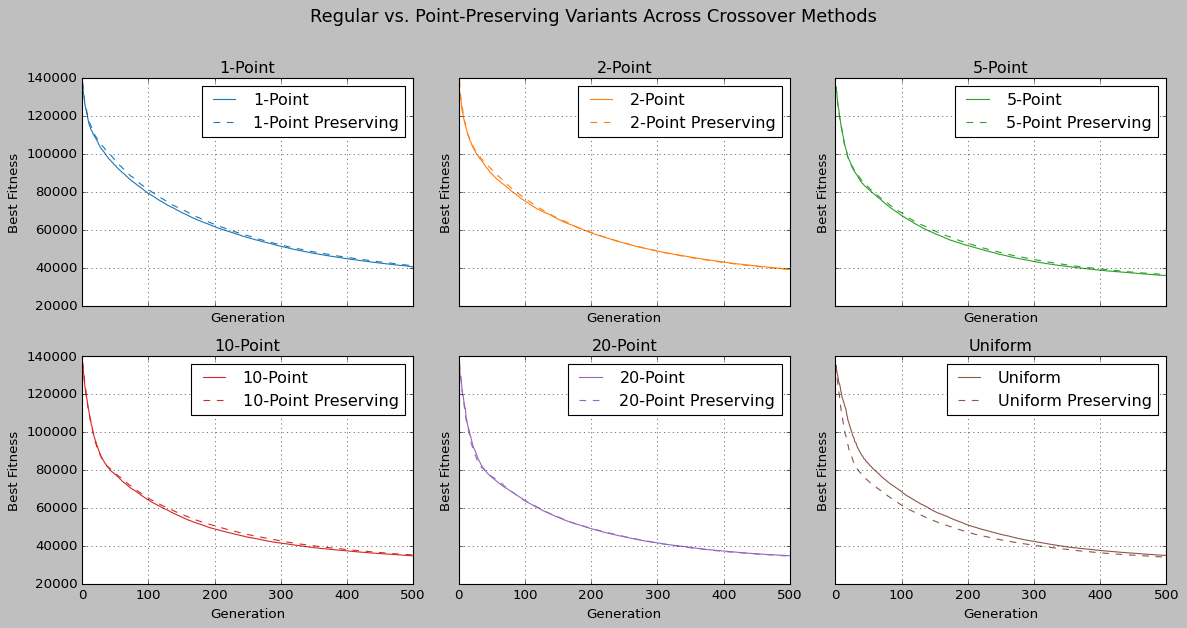

C:\Users\tygos\AppData\Local\Temp\ipykernel_23264\354507994.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_auc = df.groupby(['crossover-method', 'seed'], group_keys=False).apply(calculate_auc).reset_index()


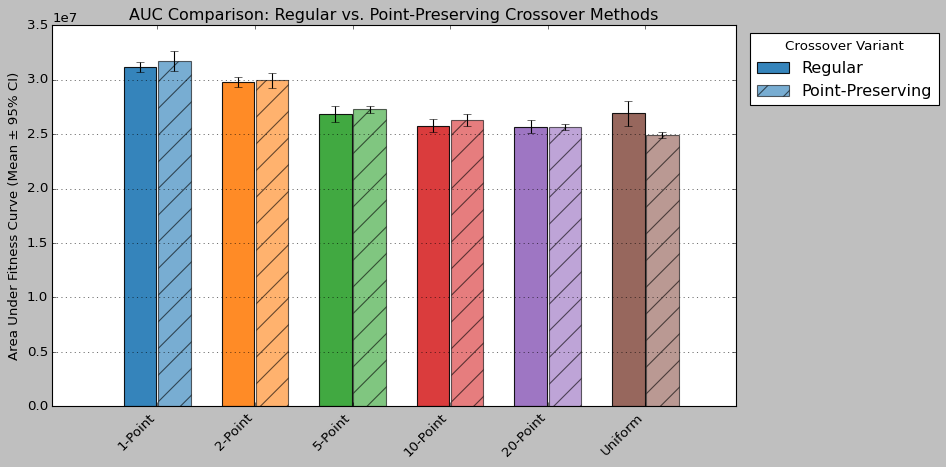

In [115]:
df = pd.read_csv("csv_files_and_graphs_voronoi-preserving/raw_data.csv")
grouped = pd.read_csv("csv_files_and_graphs_voronoi-preserving/aggregated_data.csv")

ordered_bases = ['1_POINT', '2_POINT', '5_POINT', '10_POINT', '20_POINT', 'UNIFORM']
pretty_names = {
    '1_POINT': '1-Point', '1_POINT_BLOCK': '1-Point Preserving',
    '2_POINT': '2-Point', '2_POINT_BLOCK': '2-Point Preserving',
    '5_POINT': '5-Point', '5_POINT_BLOCK': '5-Point Preserving',
    '10_POINT': '10-Point', '10_POINT_BLOCK': '10-Point Preserving',
    '20_POINT': '20-Point', '20_POINT_BLOCK': '20-Point Preserving',
    'UNIFORM': 'Uniform', 'UNIFORM_BLOCK': 'Uniform Preserving'
}
base_cmap = plt.colormaps.get_cmap('tab10')
colors = [base_cmap(i) for i in range(len(ordered_bases))]
color_map = {base: colors[i] for i, base in enumerate(ordered_bases)}

# Line plot subplots
num_cols = 3
num_rows = int(np.ceil(len(ordered_bases) / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()

for idx, base in enumerate(ordered_bases):
    ax = axes[idx]
    for variant in [base, f"{base}_BLOCK"]:
        if variant in grouped['crossover-method'].unique():
            subset = grouped[grouped['crossover-method'] == variant]
            linestyle = '--' if 'BLOCK' in variant else '-'
            ax.plot(
                subset['num-generations'],
                subset['best-fitness'],
                label=pretty_names[variant],
                linestyle=linestyle,
                color=color_map[base]
            )
    ax.set_title(pretty_names[base])
    ax.set_xlabel('Generation')
    ax.set_ylabel('Best Fitness')
    ax.legend()
    ax.grid(True)

for j in range(len(ordered_bases), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Regular vs. Point-Preserving Variants Across Crossover Methods", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("csv_files_and_graphs_voronoi-preserving/convergences.png", dpi=300)
plt.show()

def calculate_auc(group):
    return np.trapezoid(group['best-fitness'].values, group['num-generations'].values)

df_auc = df.groupby(['crossover-method', 'seed'], group_keys=False).apply(calculate_auc).reset_index()
df_auc.columns = ['crossover-method', 'seed', 'auc']

grouped_auc = df_auc.groupby('crossover-method')['auc']
means = grouped_auc.mean()
sems = grouped_auc.apply(sem)
n = grouped_auc.count()
h = sems * t.ppf(0.975, n - 1)

grouped_bars, group_labels = [], []

for base in ordered_bases:
    bars = []
    for variant in [base, f"{base}_BLOCK"]:
        if variant in means.index:
            bars.append((variant, means[variant], h[variant], 'BLOCK' if 'BLOCK' in variant else 'Regular', color_map[base]))
    if bars:
        grouped_bars.append(bars)
        group_labels.append(pretty_names[base])

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
group_spacing = bar_width * 2 + 0.1
x = np.arange(len(grouped_bars)) * (group_spacing + 0.2) - 0.1

legend_added = {}

for i, bars in enumerate(grouped_bars):
    for j, (label, mean, ci, variant, color) in enumerate(bars):
        offset = j * bar_width
        hatch = '/' if variant == 'BLOCK' else ''
        alpha = 0.6 if variant == 'BLOCK' else 0.9
        legend_key = 'Point-Preserving' if variant == 'BLOCK' else 'Regular'

        ax.bar(
            x[i] + offset,
            mean,
            yerr=ci,
            width=bar_width * 0.95,
            label=legend_key if legend_key not in legend_added else "",
            color=color,
            edgecolor='black',
            alpha=alpha,
            hatch=hatch,
            capsize=4
        )
        legend_added[legend_key] = True

tick_positions = [xi + bar_width / 2 for xi in x]
ax.set_xticks(tick_positions)
ax.set_xticklabels(group_labels, rotation=45, ha='right')

ax.set_ylabel('Area Under Fitness Curve (Mean ± 95% CI)')
ax.set_title('AUC Comparison: Regular vs. Point-Preserving Crossover Methods')
ax.grid(axis='y')
ax.legend(title='Crossover Variant', loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig("csv_files_and_graphs_voronoi-preserving/auc.png", dpi=300, bbox_inches='tight')
plt.show()
